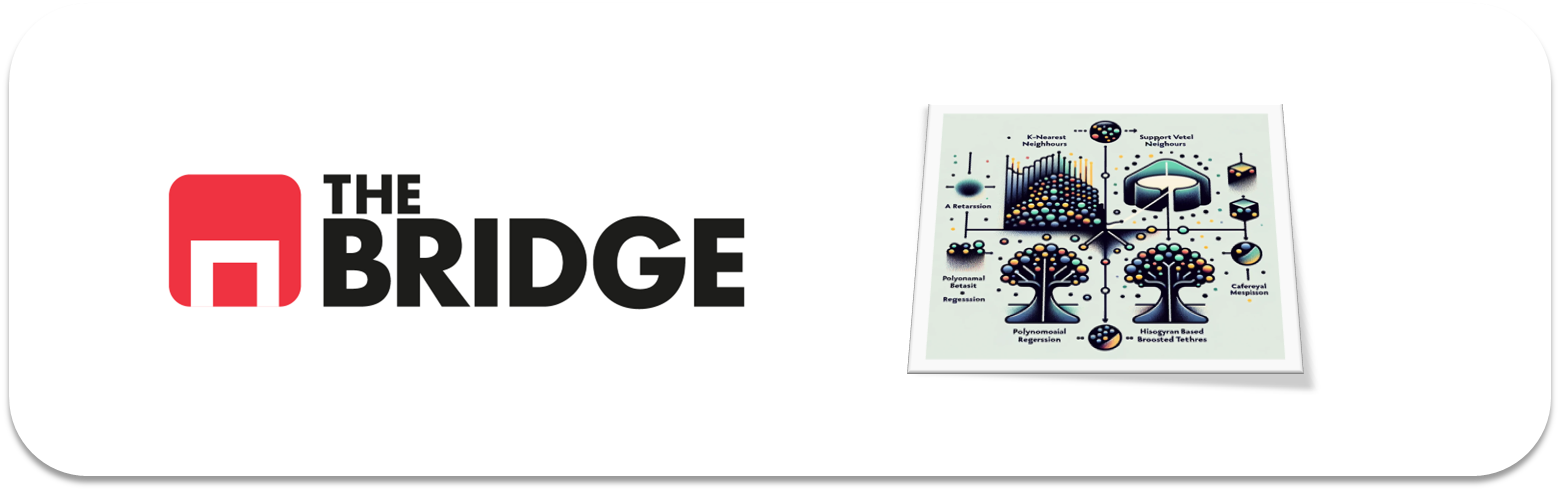

## PRACTICA OBLIGATORIA: **Otros Modelos Supervisados**

* La práctica obligatoria de esta unidad consiste en resolver un modelado de clasificación, incluyendo KNN entre los posibles modelos, y aplicando balanceado. Para ello utilizaremos un dataset que ya hemos empleado en los workout. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder

### #1. El problema y los datos

Vamos a volver al dataset con el que vimos la clasificación binaria con regresión logística, "Give me some credit", y nuestro objetivo es crear un modelo que nos permita predicir si una persona va a encontrarse en dificultades financieras en los dos próximos años. El dataset de partida lo puedes en contrar en el directorio data que acompaña al ejercicio. 

### #1.1
Cárgalo y, apoyándote en las herramientas y fuentes que consideres necesarias, haz una descripción textual de sus variables. Luego con ayuda de los datos, haz una clasificación inicial de sus variables en categóricas y numéricas.

In [2]:
df = pd.read_csv("./data/credit_npo.csv")
df

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
12532,0,0.197116,59,0,0.290216,5140.0,6,0,1,0,0.0
12533,0,0.036726,62,0,0.884985,5833.0,12,0,1,0,0.0
12534,0,0.120313,49,0,0.577676,6333.0,7,0,2,0,2.0
12535,0,0.252566,63,0,0.037640,14000.0,9,0,0,0,1.0


SeriousDlqin2yrs: Delincuencia o morosidad grave en los últimos dos años. 0 no es moroso "grave" y 1 sí es "moroso grave"  
RevolvingUtilizationOfInsecuredLines: Porcentaje de crédito prestado respecto a la cantidad total en su cuenta bancaria.  
age: Edad  
NumbreOfTime30-59DaysPastDueNotWorse: Atrasos en los pagos en esa franja de tiempo de 30 a 59 días. Morosidad leve, no como la Serious.  
DebtRatio: Ratio de deuda. Total de gastos entre total de ingresos.  
MonthlyIncome: Total de ingresos mensuales  
NumberOfOpenCreditLinesAndLoans: Número total de créditos y préstamos abiertos.  
NumberOfTimes90sDaysLate: Número de atrasos por más de 90 días. Morosidad "grave".  
NumberRealEstateLoansOrLines: Número de préstamos inmobiliarios o "sobre bienes raíces"  
NumberOfTime60-89DaysPastDueNotWorse: Atrasos en los pagos en esa franja de tiempo de 60 a 69 días. Morosidad intermedia.  
NumberOfDependents: Número de personas dependientes del solicitante.  

### #1.2
¿Qué tipo de problema estamos tratando? ¿Cuál es la variable target?

Se trata de un problema de impagos. Queremos predecir si un "cliente" o una persona que busca un crédito puede caer en morosidad grave (dos años sin pagar).  
La target, por tanto, es SeriousDlqin2yrs.

### #1.3
Pinta la distribución de frecuencias del target y coméntala

In [3]:
df.SeriousDlqin2yrs.value_counts(normalize=True)

SeriousDlqin2yrs
0    0.931084
1    0.068916
Name: proportion, dtype: float64

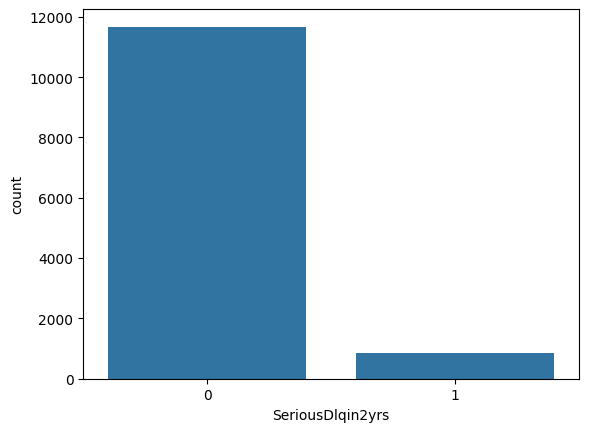

In [4]:
sns.countplot(data=df, x="SeriousDlqin2yrs")
plt.show()

Target muy desbalanceado en una proporción 93% a 7%.  
El 93% de los clientes no cayeron en morosidad grave. Hay que plantear cómo hacer el balanceo.

### #2 Modelado

Realiza un proceso completo de modelado hasta dar con el mejor modelo de los que hayas escogido (emplea al menos 3, y uno tiene que ser KNN). Aplica las técnicas que creas necesarias para obtener el mejor resultado (suponiendo que este después de hablar con el negocio es el recall medio, para tener un compromiso entre las dos clases). Para comparar modelos emplea validación cruzada antes de optimización y luego ajusta los hiperparámetros del mejor modelo. Evalúa este y haz un pequeño análisis de errores.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), int64(7)
me

In [6]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,12537.000000,12537.000000,12537.000000,12537.000000,12537.000000,11816.000000,12537.000000,12537.000000,12537.000000,12537.000000,12360.000000
mean,0.068916,0.330359,52.079445,0.409588,1.902253,6864.815420,8.482332,0.259312,0.999202,0.228364,0.822087
std,0.253321,0.368148,15.077498,4.055787,9.122216,11855.905437,5.165422,4.035658,1.134325,4.018873,1.136802
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.030651,41.000000,0.000000,0.142268,3498.750000,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.163490,51.000000,0.000000,0.302025,5416.000000,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.582219,62.000000,0.000000,0.506725,8300.000000,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,6.000000,101.000000,98.000000,99.000000,702500.000000,49.000000,98.000000,19.000000,98.000000,10.000000


In [7]:
# En un principio iba a eliminar los nulos de income, pero
# igual tenían relación esos nulos con la target, por lo que conviene revisarlo.
# Hay un poco de relación. Lo separaré en otra columna como una categoría para no perder el dato
tasa_morosos_nulos_income = df.groupby(df.MonthlyIncome.isna()).SeriousDlqin2yrs.mean()

tasa_morosos_nulos_income

MonthlyIncome
False    0.070244
True     0.047157
Name: SeriousDlqin2yrs, dtype: float64

In [8]:
# Columna nueva por lo deducido en la celda anterior
df["MonthlyIncome_ausente"] = df.MonthlyIncome.isna().astype(int)

df.MonthlyIncome_ausente.value_counts()

MonthlyIncome_ausente
0    11816
1      721
Name: count, dtype: int64

In [9]:
# Haría lo mismo con NumberOfDependents, pero en valores absolutos solo estamos analizando
# 172 clientes, de los cuales 3 son morosos. Es poco informativo para el modelo por la cantidad de datos
# relativos a la base de datos entera.
tasa_morosos_nulos_dependents = df.groupby(df.NumberOfDependents.isna()).SeriousDlqin2yrs.mean()

tasa_morosos_nulos_dependents

NumberOfDependents
False    0.069660
True     0.016949
Name: SeriousDlqin2yrs, dtype: float64

In [10]:
# De todas formas, es bueno ver si hay ceros.
# Casi todos lo son. No estaría mal imputar con 0s estos 177, que son un número bajo
# y podemos asumir que mucha gente quizá dejó sin marcar o marcó de manera extraña esa casilla al no tener
# familiares a su cargo.
df.NumberOfDependents.value_counts(dropna=False)

NumberOfDependents
0.0     6935
1.0     2384
2.0     1816
3.0      882
4.0      253
NaN      177
5.0       62
6.0       24
8.0        2
10.0       1
7.0        1
Name: count, dtype: int64

In [11]:
# Las columnas que hablan de los días parecen rarísimas y llenas de outliers
# según el describe.
# Vemos valores raros en esta primera

df["NumberOfTimes90DaysLate"].value_counts().sort_index()

NumberOfTimes90DaysLate
0     11839
1       412
2       147
3        55
4        33
5        14
6         6
7         4
8         3
9         1
10        1
13        1
98       21
Name: count, dtype: int64

In [12]:
# Mismo valor de 98 en esta otra

df["NumberOfTime30-59DaysPastDueNotWorse"].value_counts().sort_index()

NumberOfTime30-59DaysPastDueNotWorse
0     10500
1      1377
2       401
3       128
4        64
5        23
6        20
7         1
8         2
98       21
Name: count, dtype: int64

In [13]:
# Mismo valor de 98 en esta también


df["NumberOfTime60-89DaysPastDueNotWorse"].value_counts().sort_index()

NumberOfTime60-89DaysPastDueNotWorse
0     11901
1       492
2        86
3        18
4        14
5         4
11        1
98       21
Name: count, dtype: int64

In [14]:
# Todas tienen el mismo número.
# Igual que en ejercicios anteriores donde un -1 era que "no tenían datos" imagino que
# aquí el 98 signifique lo mismo.
# No podría ser lo contrario porque el resto sí son días registrados y el 98, por tanto
# son NO registrados.

# Lo curioso es que aparecen 21 veces en TODOS. Por tanto, asumo que deben ser los mismos clientes (las mismas filas).
# Si son las mismas filas, al ser tan tan pocos datos, prefiero eliminarlos.
# Compruebo:

mask_30 = df["NumberOfTime30-59DaysPastDueNotWorse"] == 98
mask_60 = df["NumberOfTime60-89DaysPastDueNotWorse"] == 98
mask_90 = df["NumberOfTimes90DaysLate"] == 98

print("¿30-59 y 90 son las mismas filas?", (mask_30 == mask_90))
print("¿60-89 y 90 son las mismas filas?", (mask_60 == mask_90))

¿30-59 y 90 son las mismas filas? 0        True
1        True
2        True
3        True
4        True
         ... 
12532    True
12533    True
12534    True
12535    True
12536    True
Length: 12537, dtype: bool
¿60-89 y 90 son las mismas filas? 0        True
1        True
2        True
3        True
4        True
         ... 
12532    True
12533    True
12534    True
12535    True
12536    True
Length: 12537, dtype: bool


In [15]:
# Son las mismas filas esos 21 así que, por ser tan poca cantidad de datos, prefiero echarlos fuera.
# Encontré este "operador" que te devuelve todo el dataframe salvo donde las filas sean el 98 en este caso
# Recordemos que mask_90 son las filas de Number of Times 90 que tienen 98.
# Como son todas la misma, barremos fácil.
df = df[~mask_90]

# Reordeno, importante que se me había olvidado
df = df.reset_index(drop=True)

In [16]:
# Ahora a buscar otras columnas sospechosas
# No voy a poner todas las que investigue a mano. Dejo siempre en celdas las que tienen algo raro
# Pero por mirar, las miro todas
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_ausente
count,12516.000000,12516.000000,12516.000000,12516.000000,12516.000000,11806.000000,12516.000000,12516.000000,12516.000000,12516.000000,12341.000000,12516.000000
mean,0.068153,0.329236,52.109060,0.245845,1.893435,6868.595291,8.496564,0.095318,1.000879,0.064318,0.823191,0.056727
std,0.252018,0.367433,15.063271,0.685011,9.078800,11860.060390,5.158044,0.506710,1.134537,0.333413,1.137194,0.231330
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.030540,41.000000,0.000000,0.143279,3500.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.162768,51.000000,0.000000,0.302373,5417.000000,8.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,0.000000,0.578673,62.000000,0.000000,0.506985,8302.500000,11.000000,0.000000,2.000000,0.000000,1.000000,0.000000
max,1.000000,6.000000,101.000000,8.000000,99.000000,702500.000000,49.000000,13.000000,19.000000,11.000000,10.000000,1.000000


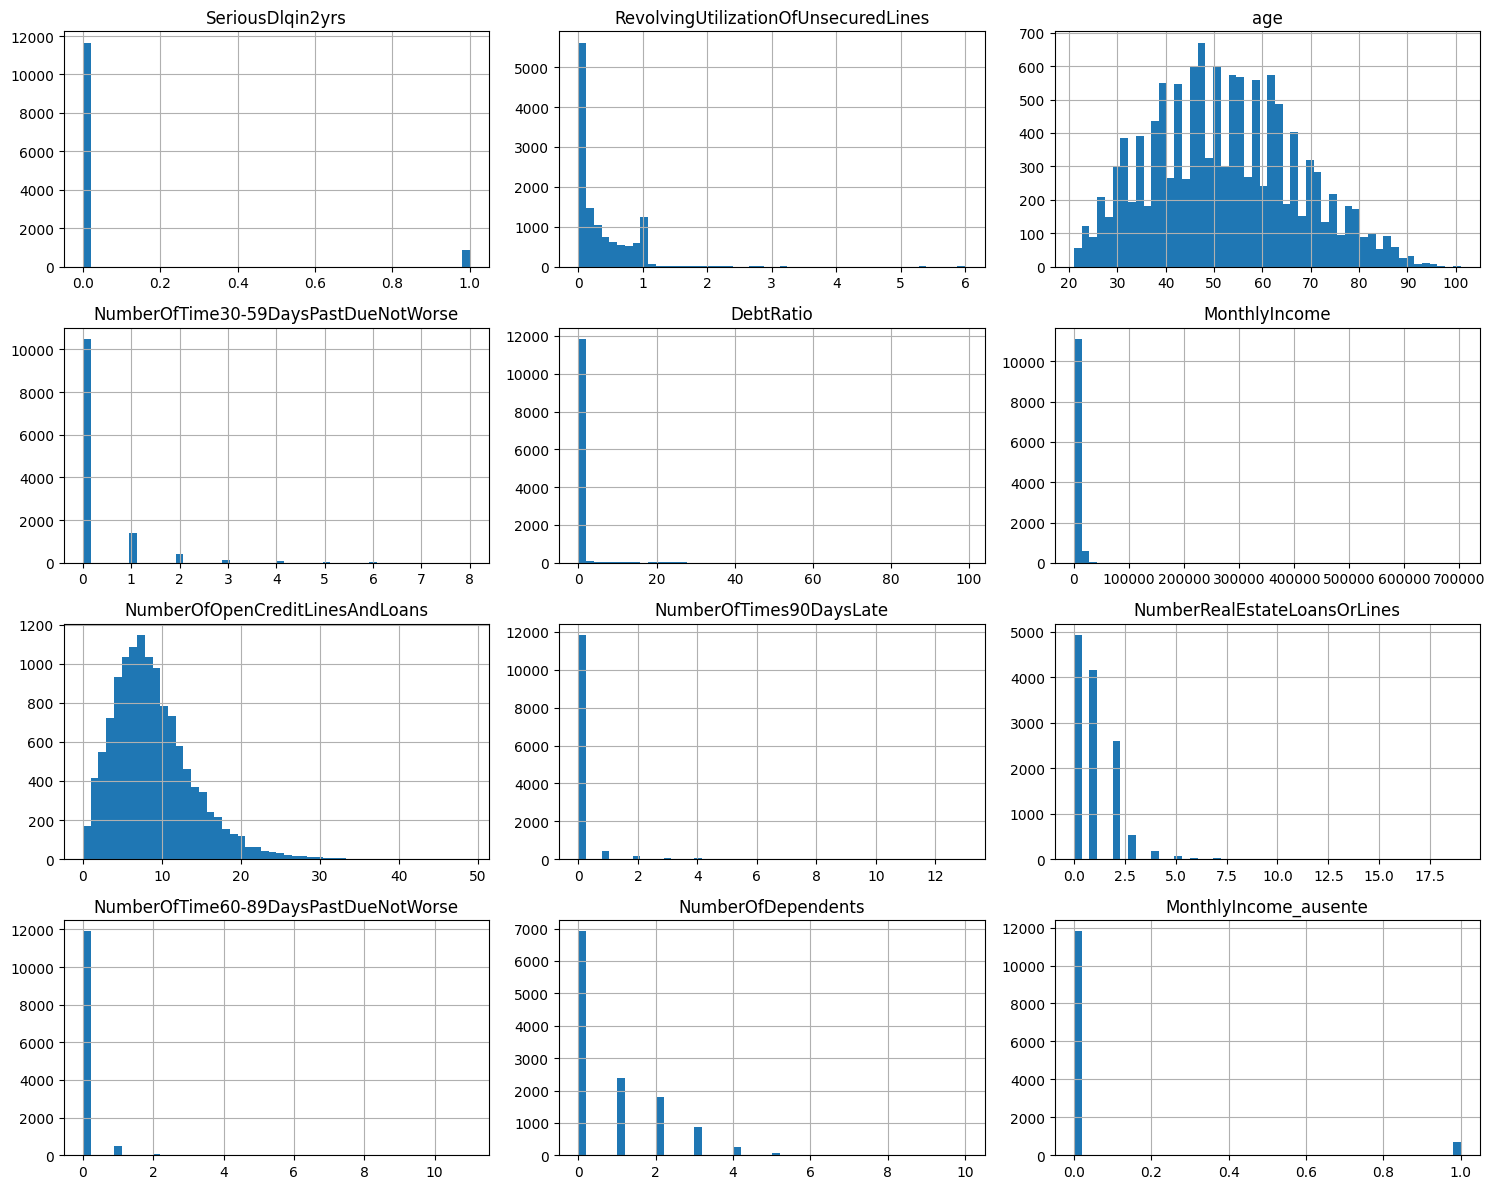

In [17]:
import matplotlib.pyplot as plt

df.hist(figsize=(15, 12), bins=50)
plt.tight_layout()
plt.show()

In [18]:
# No puede ser que haya valores por encima de 1 en revolving porque
# El 1 representa el 100% de tu crédito ya. Eso o están dando créditos por encima de lo debido
# El máximo es 6, o sea un 600% ???
# No sé bien cómo interpretar estos datos, pero voy a cruzarlos contra otras columnas para ver
# Si acaso esto indica morosidad.
# Que ya me puedo imaginar que sí y mucho.

df.RevolvingUtilizationOfUnsecuredLines.describe()

count    12516.000000
mean         0.329236
std          0.367433
min          0.000000
25%          0.030540
50%          0.162768
75%          0.578673
max          6.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

In [19]:
# Era obvio, pero había que calcularlo igual

revolving_sobre_100 = df.RevolvingUtilizationOfUnsecuredLines > 1

df.groupby(revolving_sobre_100).SeriousDlqin2yrs.mean()

RevolvingUtilizationOfUnsecuredLines
False    0.060673
True     0.407407
Name: SeriousDlqin2yrs, dtype: float64

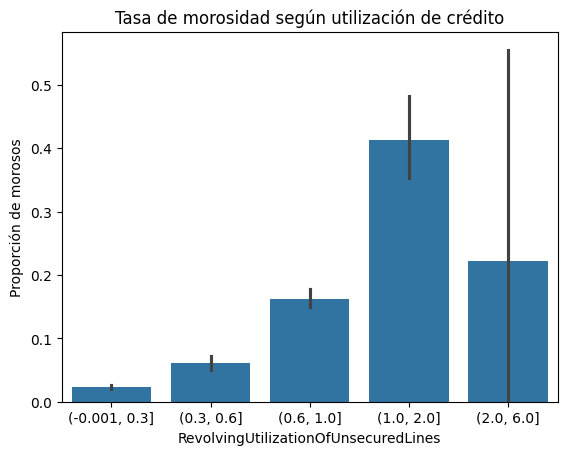

In [20]:
tramos = pd.cut(
    df.RevolvingUtilizationOfUnsecuredLines,
    bins=[0, 0.3, 0.6, 1, 2, 6],
    include_lowest=True,
)

sns.barplot(x=tramos, y=df.SeriousDlqin2yrs)
plt.title("Tasa de morosidad según utilización de crédito")
plt.ylabel("Proporción de morosos")
plt.show()

En el barplot se demuestra clarísimamente la relación entre porcentaje de crédito prestado y la morosidad.  
No creo que deba tratar estos "outliers" de manera convencional, pero sí me atrevería a encapsular  
los valores que estén por encima del 100% porque demuestran ser claros indicadores de peligro.  
Ya habíamos visto en otros ejercicios columnas con valores capados y ahora entiendo por qué pueden ser importantes.  

In [21]:
# Tuve que buscar muchísimo para entender cómo se cappea
# Lo que hace el capado realmente no es categorizar, sino APLASTAR los valores
# Me viene bien para el KNN para que no me ocurra lo que le pasó a Jaime en el workout
# Elijo el 2 porque los valores entre 1 y 2 son bastante distintos del resto, pero no quiero que el resto
# desvíe tanto la atención del KNN por así decirlo

df["RevolvingUtilizationOfUnsecuredLines"] = df.RevolvingUtilizationOfUnsecuredLines.clip(upper=2)

In [22]:
# DebtRatio es la otra a la que tenemos que mirar por si acaso
# Al ser gastos / ingreso, si ingreso es 0 tendríamos algún valor infinito
# Esto lo aprendí de la TeamChallenge toolkit! Pero como no recuerdo cómo instalarlo para
# pasar el toolkit que hice, lo miramos a mano y listo.

df.DebtRatio.value_counts().sort_values(ascending=False)

DebtRatio
0.000000    415
4.000000     24
1.000000     19
2.000000     17
3.000000     16
           ... 
0.290216      1
0.884985      1
0.577676      1
0.037640      1
0.455357      1
Name: count, Length: 11544, dtype: int64

In [23]:
# Y esto está bien, demuestra un poco lo que esperaba, pero no está del todo bien
# Porque dentro de los monthly income_ausente hay ingresos cero también y debo tenerlos en cuenta
# Por tanto, en realidad tenemos TRES categorías que analizar si pudiera (a ver si puedo hacerlo)
# Una con ingresos, otra con ingresos a cero y otra con los ingresos sin declarar.
# La segunda es la que no estamos revisando.

df.groupby("MonthlyIncome_ausente").DebtRatio.describe()

,count,mean,std,min,25%,50%,75%,max
MonthlyIncome_ausente,,,,,,,,
0,11806.0,0.500105,2.697173,0.0,0.143971,0.294881,0.477515,96.0
1,710.0,25.061972,27.639409,0.0,0.000000,15.000000,42.000000,99.0


In [24]:
# Voy paso a paso antes de volverme loco
# Cantidad de ingresos a cero
ingresos_cero = (df.MonthlyIncome == 0).sum()
ingresos_cero

np.int64(33)

In [25]:
# Ver cómo afectan (aunque solo sean 33) al debt ratio
# Seguramente parecido a lo que hace que no tengas ingresos.
# Y además son los que crean los outliers dentro de la propia monthlyIncome
# Se puede ver en el max 96

df.loc[df.MonthlyIncome == 0, "DebtRatio"].describe()

count    33.000000
mean     26.909091
std      32.009143
min       0.000000
25%       0.000000
50%       8.000000
75%      56.000000
max      96.000000
Name: DebtRatio, dtype: float64

In [26]:
# Muy parecido, le hace lo mismo al dividir entre cero digamos.

df.loc[df.MonthlyIncome_ausente == 1, "DebtRatio"].describe()

count    710.000000
mean      25.061972
std       27.639409
min        0.000000
25%        0.000000
50%       15.000000
75%       42.000000
max       99.000000
Name: DebtRatio, dtype: float64

In [27]:
# Reviso algo que tendría que haber mirado antes y es la cantidad de ingresos muy bajos.
df.MonthlyIncome.value_counts().sort_index()

MonthlyIncome
0.0         33
1.0         14
50.0         1
100.0        3
135.0        1
            ..
251608.0     1
287662.0     1
304000.0     1
629000.0     1
702500.0     1
Name: count, Length: 4166, dtype: int64

In [28]:
# SOLUCIÓN (espero que sea la mejor)
# Los 1s de monthly income tampoco son demasiados, no van a empujar tanto, los meta donde los meta
# El tratamiento de ceros y de valores que faltaban sí es necesario.

# 1. El ingreso a 0 lo convertimos a NaN para unificar. Esto ya se ha hecho varias veces, sé que está bien
df.loc[df.MonthlyIncome == 0, "MonthlyIncome"] = np.nan

# 2. Recalcular para capturar tanto el nan como los ceros otra vez
df["MonthlyIncome_ausente"] = df.MonthlyIncome.isna().astype(int)

# 3) DebtRatio está roto en todas esas filas: lo marcamos como nulo
df.loc[df.MonthlyIncome_ausente == 1, "DebtRatio"] = np.nan

Aunque esto parezca una locura, en mi cabeza tiene sentido:  
Si ahora mismo imputo valores, me estoy cargando o contaminando el modelo antes de empezar. La imputación de valores solo puede ir durante el tratado de train-test.  
Los meto como NaN, que es lo que son, y así me "digo a mí mismo" que esto hay que rellenarlo con algo.  

In [29]:
# como se puede ver, hay nulos, poero son nulos que sé cómo tratar e imputar
# Pero esa imputación vendrá después, durante la fase de modelado
# BTW: No sé si se dice "modelado" a esa fase, pero me refiero a todo lo que viene después de hacer el split
# De hecho, creo que esto es el pipeline

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12516 entries, 0 to 12515
Data columns (total 12 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12516 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12516 non-null  float64
 2   age                                   12516 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12516 non-null  int64  
 4   DebtRatio                             11773 non-null  float64
 5   MonthlyIncome                         11773 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12516 non-null  int64  
 7   NumberOfTimes90DaysLate               12516 non-null  int64  
 8   NumberRealEstateLoansOrLines          12516 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12516 non-null  int64  
 10  NumberOfDependents                    12341 non-null  float64
 11  MonthlyIncome_ausente     

## Train y Test:

In [30]:
X = df.drop(columns=["SeriousDlqin2yrs"])
y = df.SeriousDlqin2yrs

In [31]:
# Train y test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [32]:
X_train.shape

(10012, 11)

In [33]:
X_test.shape

(2504, 11)

In [34]:
y_train.value_counts(normalize=True)

SeriousDlqin2yrs
0    0.931882
1    0.068118
Name: proportion, dtype: float64

In [35]:
y_train.value_counts(normalize=True)

SeriousDlqin2yrs
0    0.931882
1    0.068118
Name: proportion, dtype: float64

In [36]:
# Para imputar esos nans ahora en el train
# voy a probar el SimpleImputer

from sklearn.impute import SimpleImputer

# Como argumento se le puede pasar con qué quieres que impute
imputer = SimpleImputer(strategy="median")

# y después es igualito al standardScaler

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

In [ ]:
# Cero nans, bien imputado
np.isnan(X_train_imputed).sum()

np.int64(0)

In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [49]:
# KNN al fin, aunque por el tipo de datos auguro que no va a ser muy bueno aquí
# El stratifiedKFold es para la y desbalanceada
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn = KNeighborsClassifier()

scores = cross_val_score(knn, X_train_scaled, y_train, scoring="recall_macro", cv=cv)
scores.mean()


np.float64(0.5901152899021932)

In [51]:
# Testeo de una pipeline
# Esto no sale de la nada, esto es porque más adelante me di cuenta de que todo el proceso era repetitivo
# y me terminé haciendo una función para poder automatizarlo todo.
# Gracias a esa "mala idea" encontré las pipelines, aunque sé que no tocan aún, pero me apetecía probarlo.

from sklearn.pipeline import Pipeline

pipeline_knn = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier()),
])

In [ ]:
# Un poco mejor, pero no mucho. Lo interesante es que le puedes pasar la X_train del principio
# y ya te hace toda la imputación, el escalado o lo que le digas en los pasos.
# Súper útil, aunque entiendo por qué no lo vimos desde el principio.

scores_pipeline = cross_val_score(pipeline_knn, X_train, y_train, scoring="recall_macro", cv=cv)
scores_pipeline.mean()

np.float64(0.5910113557240203)

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report

y_pred_cv = cross_val_predict(pipeline_knn, X_train, y_train, cv=cv)

print(classification_report(y_train, y_pred_cv))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      9330
           1       0.48      0.20      0.28       682

    accuracy                           0.93     10012
   macro avg       0.71      0.59      0.62     10012
weighted avg       0.91      0.93      0.92     10012



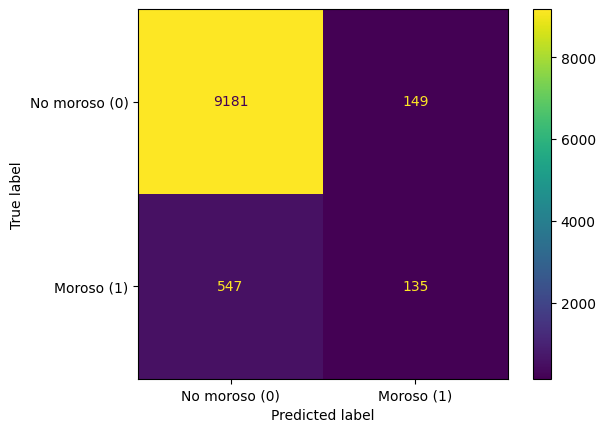

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_train, y_pred_cv,
    display_labels=["No moroso (0)", "Moroso (1)"]
)
plt.show()